<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 177.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 151.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 160.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 125.9 MB/s eta 0:00:00


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-03-12 17:13:49--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  38.6MB/s    in 3.9s    

2026-03-12 17:13:53 (39.2 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



NaN values before cleaning: 42002
NaN values after cleaning: 0


 number of deleted outliers: 316


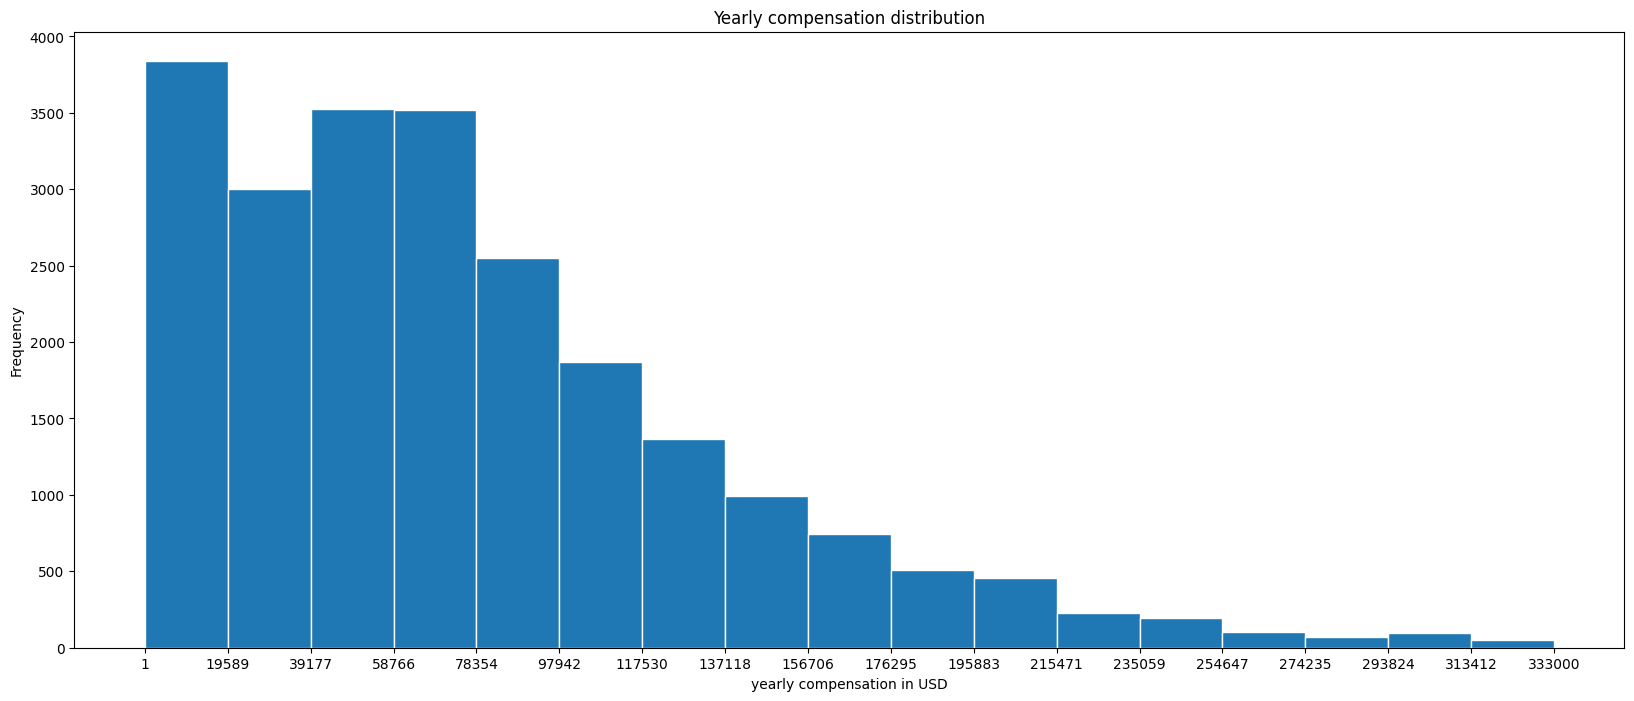

In [3]:
## Write your code here

df_comp=df['ConvertedCompYearly'].copy()

print('NaN values before cleaning:', df_comp.isnull().sum())    # broader analysis of this column is in data_wrangling/09_imput_missing_values
df_comp=df_comp.dropna()
print('NaN values after cleaning:', df_comp.isnull().sum())

Q1=np.quantile(df_comp, 0.25)      
Q3=np.quantile(df_comp, 0.75)
IQR=Q3-Q1
upper_bound=Q3+3*IQR                                       # use a wider IQR threshold because compensation data is strongly right-skewed
lower_bound=Q1-1.5*IQR

df_comp_clean=df_comp[
    (df_comp>lower_bound) &
    (df_comp<upper_bound)
]
   
print('\n\n number of deleted outliers:', df_comp.shape[0]-df_comp_clean.shape[0])

entries_in_bin, bin_range=np.histogram(df_comp_clean,17)

df_comp_clean.plot(
    kind='hist'
    ,figsize=(20,8)
    ,xticks=bin_range
    ,bins=17
    ,linewidth=1
    ,edgecolor='white'
    ,title='Yearly compensation distribution'
    ,xlabel='yearly compensation in USD'
)
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



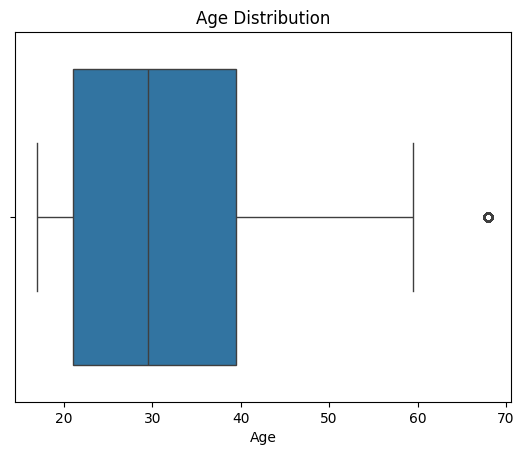

In [4]:
## Write your code here

age=df['Age'].copy()

age=age[age!='Prefer not to say']        # remove non-informative age responses

age=age.replace({
    'Under 18 years old':17              # convert age ranges to approximate numeric midpoints
    ,'18-24 years old':21
    ,'25-34 years old':29.5
    ,'35-44 years old':39.5
    ,'45-54 years old':49.5
    ,'55-64 years old':59.5
    ,'65 years or older':68
})

age=pd.to_numeric(age,errors='coerce')
age = age.dropna()

sns.boxplot(x=age)
plt.xlabel('Age')
plt.title('Age Distribution')
plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



null values before cleaning 42002


null values after cleaning 0


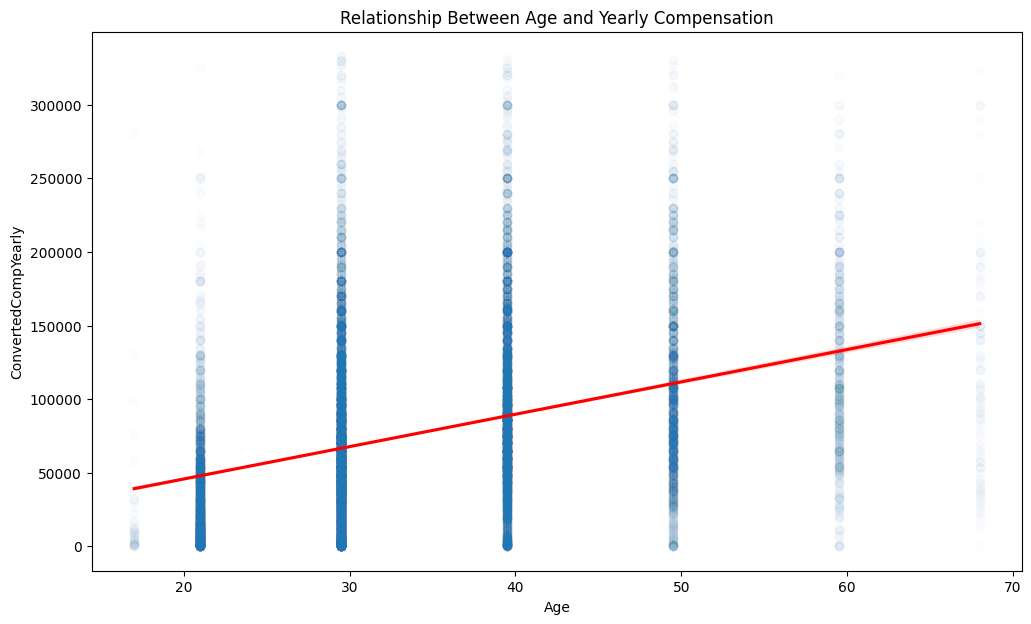

In [5]:
## Write your code here

comp_age=df[['Age','ConvertedCompYearly']].copy()

print('null values before cleaning',comp_age['ConvertedCompYearly'].isnull().sum())
comp_age=comp_age.dropna(subset=['ConvertedCompYearly'])
print('\n\nnull values after cleaning',comp_age['ConvertedCompYearly'].isnull().sum())

comp_age=comp_age[comp_age['Age']!='Prefer not to say']                                   # remove non-informative age responses

comp_age=comp_age[(
    (comp_age['ConvertedCompYearly']>lower_bound) &                                       # remove extreme salary outliers using previously calculated IQR bounds
    (comp_age['ConvertedCompYearly']<upper_bound)
)]

comp_age['Age']=comp_age['Age'].replace({                                                 # convert age ranges to approximate numeric midpoints
    'Under 18 years old':17
    ,'18-24 years old':21
    ,'25-34 years old':29.5
    ,'35-44 years old':39.5
    ,'45-54 years old':49.5
    ,'55-64 years old':59.5
    ,'65 years or older':68
})

comp_age['Age']=pd.to_numeric(comp_age['Age'],errors='coerce')
comp_age = comp_age.dropna(subset=['Age'])

plt.figure(figsize=(12,7))
sns.regplot(
    data=comp_age
    ,x='Age'
    ,y='ConvertedCompYearly'
    ,line_kws={'color':'red'}
    ,scatter_kws={'alpha':0.01}
)
plt.title('Relationship Between Age and Yearly Compensation')
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


In [6]:
## Write your code here

comp_sat=df[['Age','ConvertedCompYearly','JobSatPoints_6']].copy()

print('null values before cleaning\n\n',comp_sat[['JobSatPoints_6','ConvertedCompYearly']].isnull().sum())
comp_sat=comp_sat.dropna(subset=['JobSatPoints_6','ConvertedCompYearly'])
print('\n\n\nnull values after cleaning\n\n',comp_sat[['JobSatPoints_6','ConvertedCompYearly']].isnull().sum())

comp_sat=comp_sat[comp_sat['Age']!='Prefer not to say']                  # remove non-informative age responses

comp_sat=comp_sat[(
    (comp_sat['ConvertedCompYearly']>lower_bound) &
    (comp_sat['ConvertedCompYearly']<upper_bound)
)]

comp_sat['Age']=comp_sat['Age'].replace({                         # convert age ranges to approximate numeric midpoints
    'Under 18 years old':17
    ,'18-24 years old':21
    ,'25-34 years old':29.5
    ,'35-44 years old':39.5
    ,'45-54 years old':49.5
    ,'55-64 years old':59.5
    ,'65 years or older':68
})

comp_sat['Age']=pd.to_numeric(comp_sat['Age'],errors='coerce')
comp_sat = comp_sat.dropna(subset=['Age'])

null values before cleaning

 JobSatPoints_6         35987
ConvertedCompYearly    42002
dtype: int64



null values after cleaning

 JobSatPoints_6         0
ConvertedCompYearly    0
dtype: int64


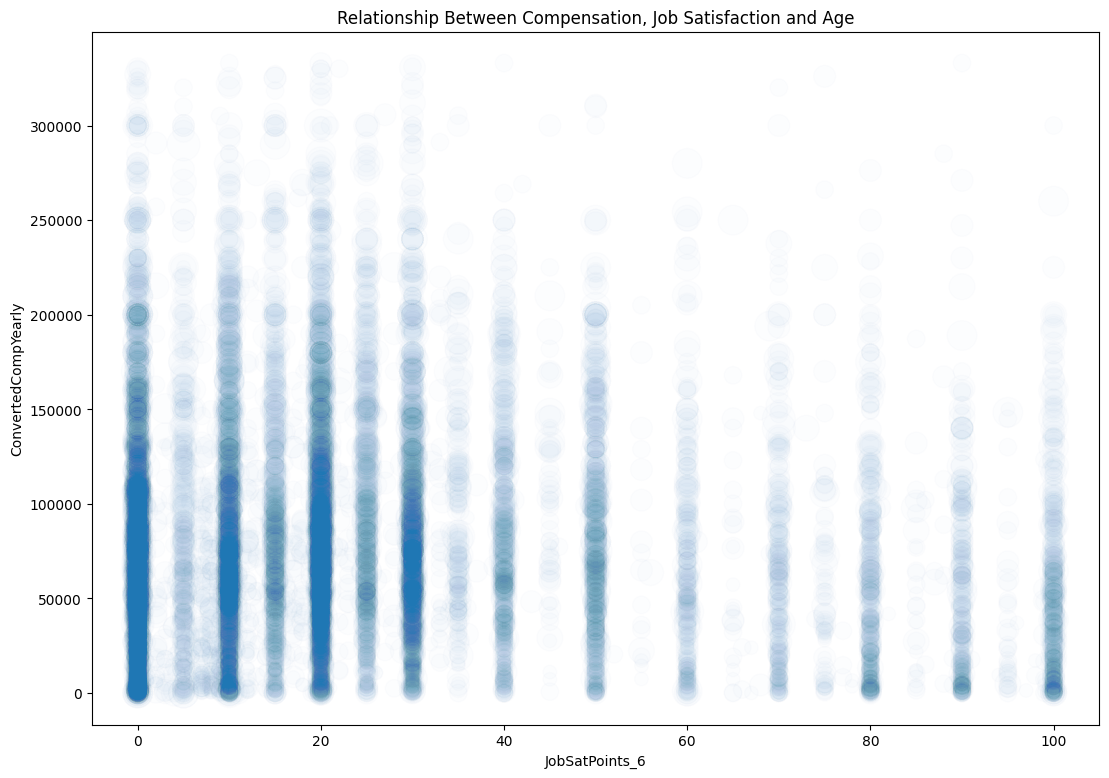

In [7]:
comp_sat.plot(
    kind='scatter'
    ,x='JobSatPoints_6'
    ,y='ConvertedCompYearly'
    ,s=comp_sat['Age']**1.5    # scale bubble size using age values (nonlinear scaling improves visibility)
    ,alpha=0.01
    ,figsize=(13,9)
    ,title='Relationship Between Compensation, Job Satisfaction and Age'
)
plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



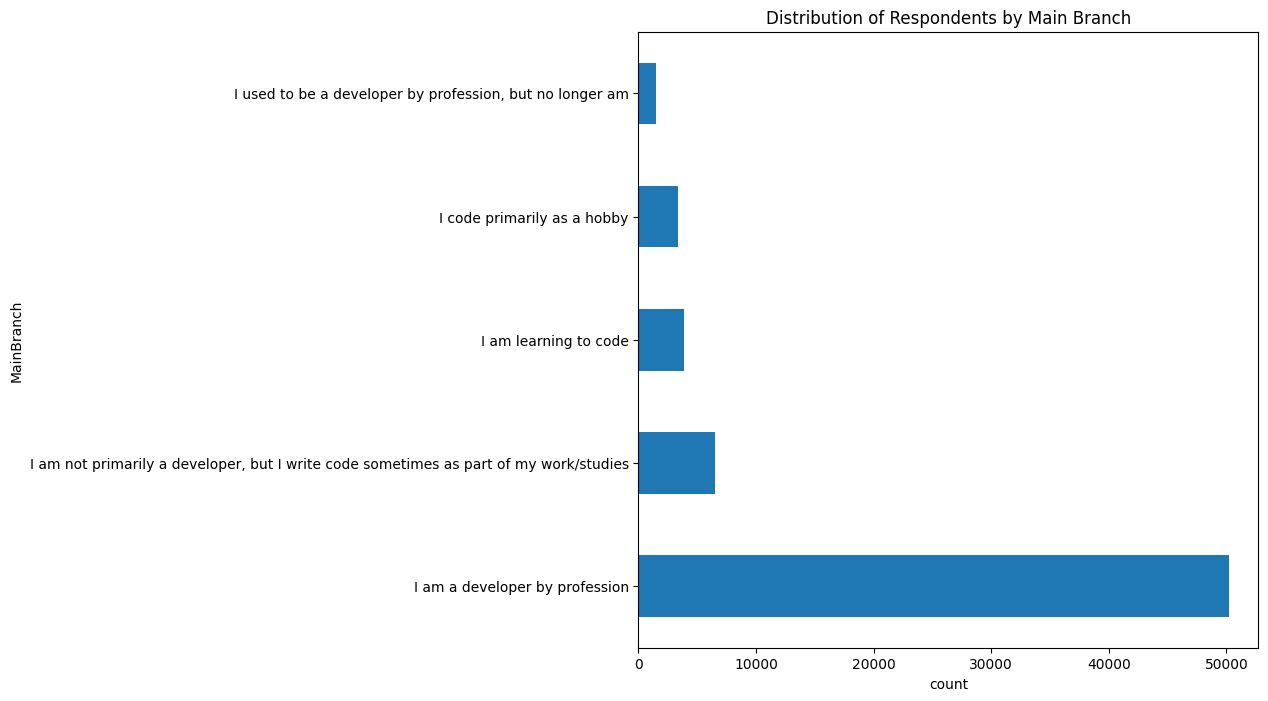

In [8]:
## Write your code here

main_branch=df['MainBranch'].value_counts()

main_branch.plot(
    kind='barh'
    ,figsize=(8,8)
    ,title='Distribution of Respondents by Main Branch'
    ,xlabel='count'
)
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



null values before cleaning LanguageWantToWorkWith    9685
dtype: int64


null values after cleaning LanguageWantToWorkWith    0
dtype: int64


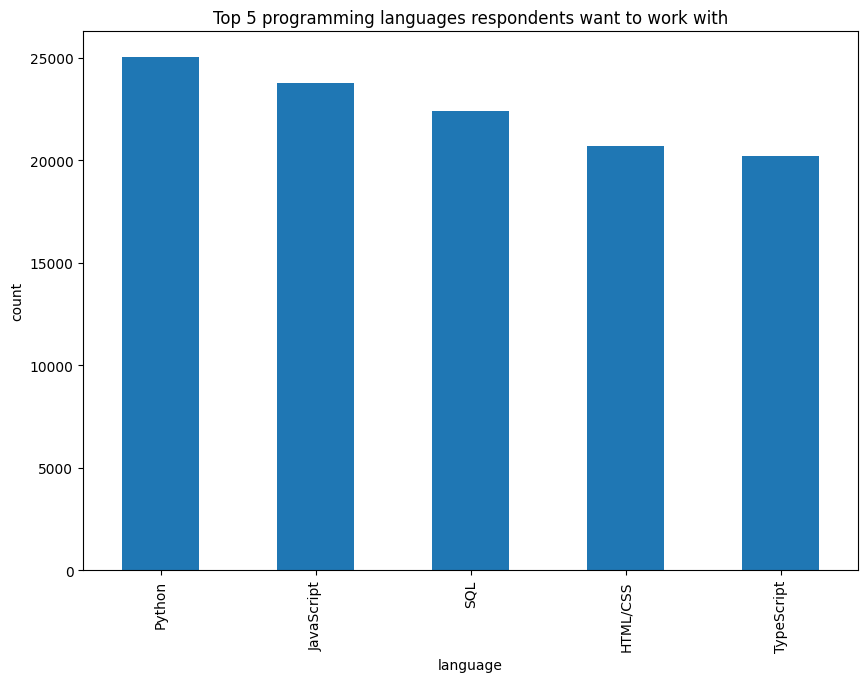

In [9]:
## Write your code here

lang=df[['LanguageWantToWorkWith']].copy()

print('null values before cleaning',lang.isnull().sum())
lang=lang.dropna()
print('\n\nnull values after cleaning',lang.isnull().sum())

lang['language']=lang['LanguageWantToWorkWith'].str.split(';')
lang=lang.explode('language')                                                                                # Split responses containing multiple programming languages into separate rows so each language can be analyzed individually

top5lang=lang['language'].value_counts().head(5)

top5lang.plot(
    kind='bar'
    ,figsize=(10,7)
    ,ylabel='count'
    ,title='Top 5 programming languages respondents want to work with'
)
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


null values before cleaning

 JobSatPoints_6    35987
JobSatPoints_7    35989
dtype: int64



null values after cleaning

 JobSatPoints_6    0
JobSatPoints_7    0
dtype: int64


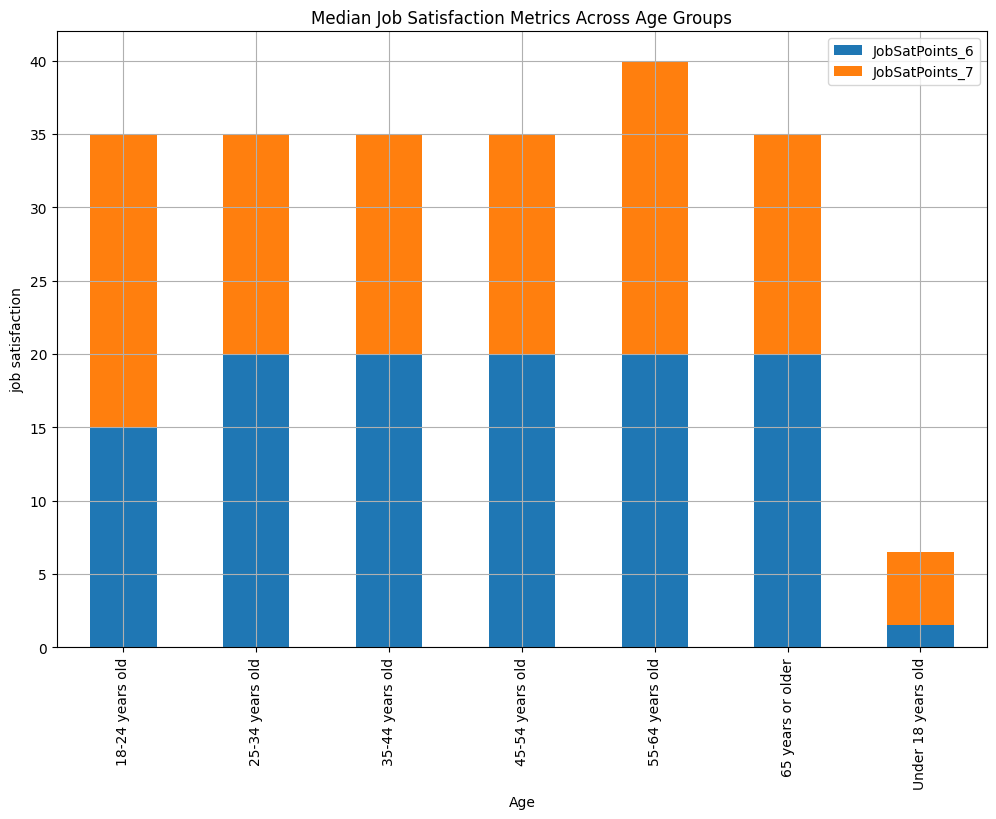

In [10]:
## Write your code here

age_sat=df[['JobSatPoints_6','JobSatPoints_7','Age']].copy()

print('null values before cleaning\n\n',age_sat[['JobSatPoints_6','JobSatPoints_7']].isnull().sum())
age_sat=age_sat.dropna(subset=['JobSatPoints_6','JobSatPoints_7'])
print('\n\n\nnull values after cleaning\n\n',age_sat[['JobSatPoints_6','JobSatPoints_7']].isnull().sum())

age_sat=age_sat[age_sat['Age']!='Prefer not to say']                                        # remove non-informative age responses

grouped_age_sat=age_sat.groupby('Age')[['JobSatPoints_6','JobSatPoints_7']].median()

grouped_age_sat.plot(
    kind='bar'
    ,stacked=True
    ,grid=True
    ,figsize=(12,8)
    ,title='Median Job Satisfaction Metrics Across Age Groups'
    ,ylabel='job satisfaction'
)
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



null values before cleaning DatabaseHaveWorkedWith    15183
dtype: int64


null values after cleaning DatabaseHaveWorkedWith    0
dtype: int64


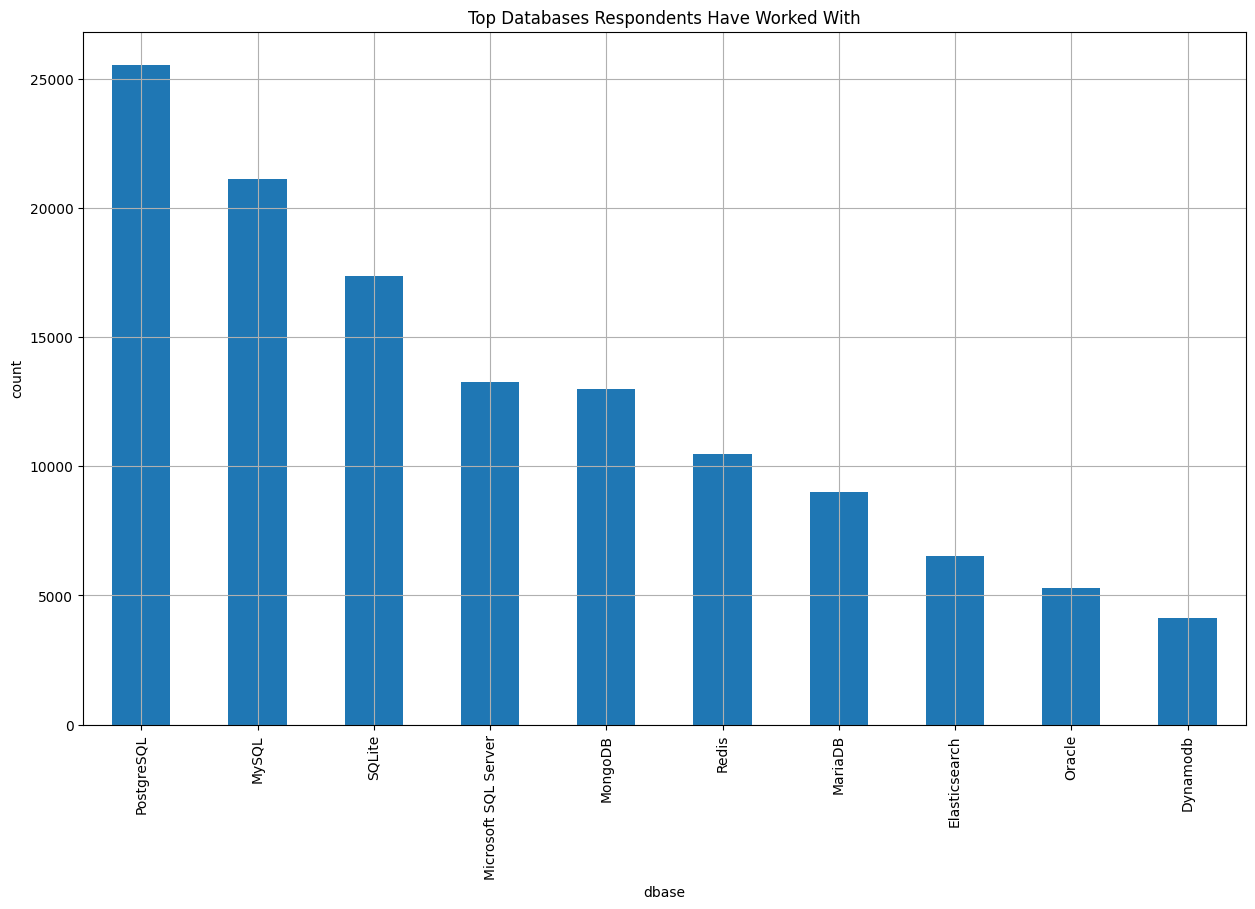

In [11]:
## Write your code here

dbase=df[['DatabaseHaveWorkedWith']].copy()

print('null values before cleaning',dbase.isnull().sum())
dbase=dbase.dropna()
print('\n\nnull values after cleaning',dbase.isnull().sum())

dbase['dbase']=dbase['DatabaseHaveWorkedWith'].str.split(';')
dbase=dbase.explode('dbase')                                       # Split responses containing multiple databases into separate rows so each database can be analyzed individually

top10db=dbase['dbase'].value_counts().head(10)                     # Keep only the 10 most frequently used databases to improve readability

top10db.plot(
    kind='bar'
    ,grid=True
    ,figsize=(15,9)
    ,ylabel='count'
    ,title='Top Databases Respondents Have Worked With'
)
plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a bar chart.



In [12]:
comp_age.head(10)

,Age,ConvertedCompYearly
72,21.0,7322.0
374,29.5,30074.0
379,39.5,91295.0
385,39.5,53703.0
389,29.5,110000.0
392,39.5,161044.0
395,49.5,121018.0
398,49.5,195000.0
403,39.5,44586.0
409,59.5,57999.0


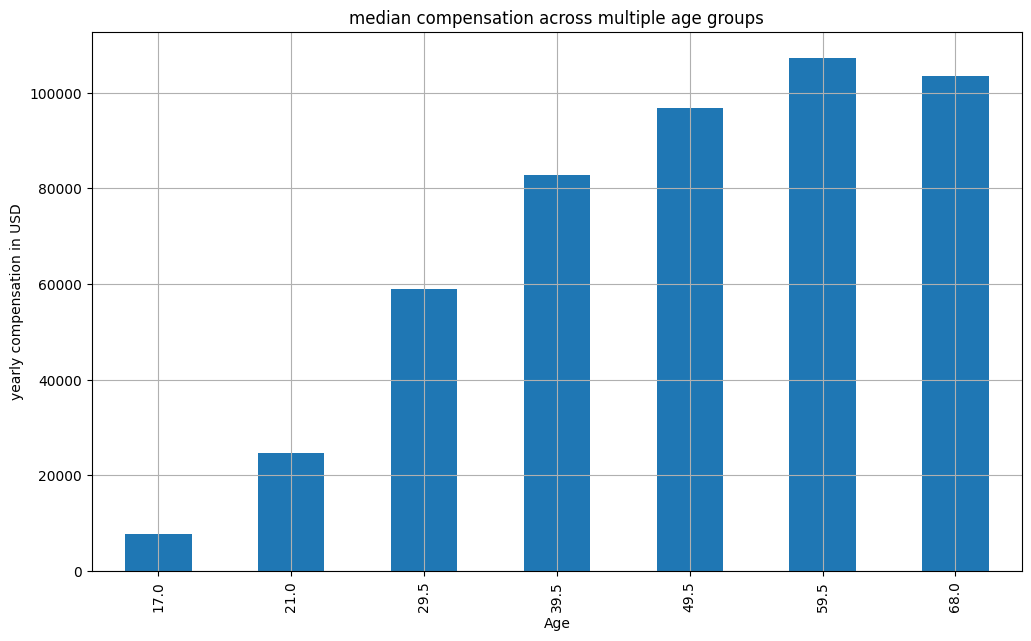

In [13]:
## Write your code here

median_comp_by_age=comp_age.groupby('Age')['ConvertedCompYearly'].median()

median_comp_by_age.plot(
    kind='bar'
    ,grid=True
    ,figsize=(12,7)
    ,ylabel='yearly compensation in USD'
    ,title='median compensation across multiple age groups'
)
plt.show()

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



null values before cleaning 6507


null values after cleaning 0


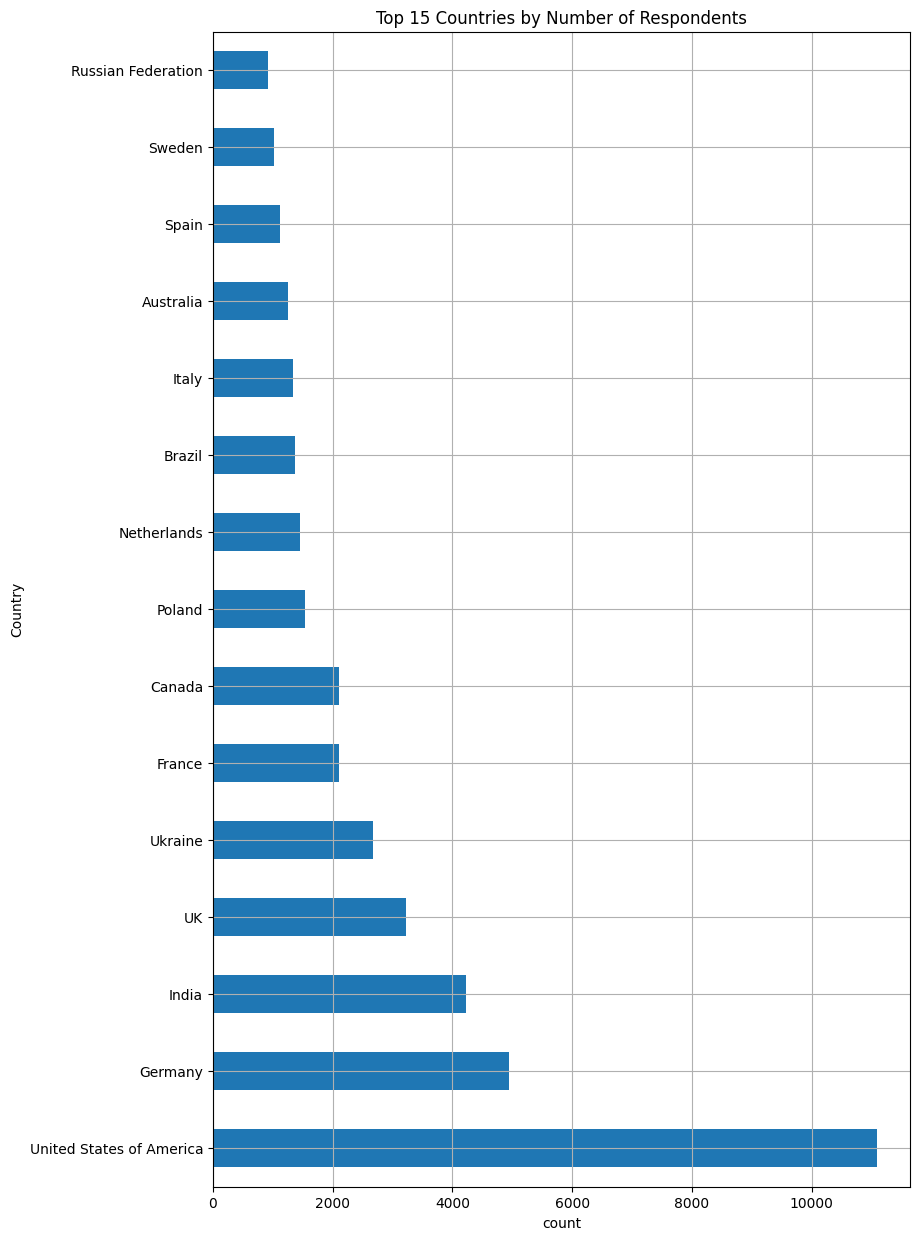

In [14]:
## Write your code here

Country=df['Country'].copy()

print('null values before cleaning',Country.isnull().sum())
Country=Country.dropna()
print('\n\nnull values after cleaning',Country.isnull().sum())

top15countries=Country.value_counts().head(15)

top15countries=top15countries.rename(index={'United Kingdom of Great Britain and Northern Ireland':'UK'})

top15countries.plot(
    kind='barh'
    ,grid=True
    ,figsize=(9,15)
    ,xlabel='count'
    ,title='Top 15 Countries by Number of Respondents'
)
plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
